In [ ]:
import numpy as np
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from pathlib import Path
from numpy import linalg as LA
from sklearn.base import BaseEstimator
from tqdm import trange
import pandas as pd
import pickle
import os
import math
import time
from tqdm import tqdm
import copy
import pickle

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from scipy import stats

In [ ]:
from sklearn.linear_model import ElasticNet

In [ ]:
def geometric_noise(U,epsilon,size):
  g1 = np.random.geometric(1 - np.exp(-epsilon), size=size) - 1  # G1 ~ Geom(1-p)
  g2 = np.random.geometric(1 - np.exp(-epsilon), size=size) - 1  # G2 ~ Geom(1-p)
  noise=g1-g2+U*1.5
  noise[np.where(noise<U)]=U
  noise[np.where(noise>2*U)]=2*U
  if size==1:
    noise=noise[0]
  return noise.astype(int)

In [ ]:
class PrefixSum_fixed_length:
    def __init__(self, T, epsilon,delta,size):
        self.T = T
        self.epsilon = epsilon
        self.delta=delta
        self.max_level = int(np.ceil(np.log2(T))) + 1  # Max tree depth needed
        self.noisy_partial_sums = {}  # {level: {index: noisy_value}}
        self.size=size

        # Precompute all Laplace noise for power-of-two intervals
        self._precompute_noise()
        self._private_prefix_sum_noise()


    def _precompute_noise(self):
        for level in range(self.max_level):
            self.noisy_partial_sums[level] = {}
            nodes_at_level = (self.T) // (1 << level)
            self.noisy_partial_sums[level] = np.random.laplace(0, np.log2(self.T)/self.epsilon,[self.size,nodes_at_level])

    def _private_prefix_sum_noise(self):

        self.value = []
        # Decompose t into a sum of power-of-two intervals
        for t in range(1,self.T+1):
          total=np.zeros(self.size)
          remaining = t
          level = 0
          while remaining > 0:
              # Check if the current bit is set in the binary representation
              if remaining & 1:
                  node_idx = (remaining - 1) >> level
                  total += self.noisy_partial_sums[level][:,node_idx]
              remaining >>= 1
              level += 1
          self.value.append(total)
        return total

In [ ]:
class PrefixSum:
  def __init__(self,epsilon,delta,size):
    self.epsilon=epsilon
    self.delta=delta
    self.values=[]
    self.power_series=[]
    self.cnt=0
    self.power_cnt=0
    self.true_value=[]
    self.prefixsum=PrefixSum_fixed_length(1,self.epsilon,self.delta,1)
    self.noise_sum=[]
    self.size=size

  def query(self,num):
    self.cnt+=1
    self.true_value.append(num)
    if math.log2(self.cnt).is_integer():
      self.power_cnt=self.cnt
      self.power_series.append(np.random.laplace(0,1/self.epsilon,self.size)+np.sum(self.true_value,axis=0))
      self.prefixsum=PrefixSum_fixed_length(self.cnt,self.epsilon,self.delta,self.size)
      self.noise_sum.append(self.power_series[-1])
      return self.power_series[-1]
    else:
      self.noise_sum.append(self.power_series[-1]+self.prefixsum.value[self.cnt-self.power_cnt]+np.sum(self.true_value[self.power_cnt-1:self.cnt-1],axis=0))
      return self.power_series[-1]+self.prefixsum.value[self.cnt-self.power_cnt]+np.sum(self.true_value[self.power_cnt-1:self.cnt-1],axis=0)

In [ ]:
class randbin:
  def __init__(self,epsilon,delta,U):
    self.epsilon=epsilon
    self.delta=delta
    self.buffer=[]
    self.bins=[]
    self.E=np.log2(1/self.delta)*30/self.epsilon
    self.true_value=[]
    self.cnt=0
    self.U=U
    self.rho=[geometric_noise(U,epsilon,1)]
    self.prefixsum=PrefixSum(epsilon,delta,1)
    self.S=[self.prefixsum.query(self.rho[0])]


  def query(self,element):
    self.cnt+=1
    self.true_value.append(element)
    self.buffer.append(element)

    if self.cnt>=self.E+self.U+self.S[-1]:
      bin=self.buffer[0:self.rho[-1]-1]
      del self.buffer[0:self.rho[-1]-1]
      self.bins.append(bin)
      self.rho.append(geometric_noise(self.U,self.epsilon,1))
      self.S.append(self.prefixsum.query(self.rho[-1]))
      return bin,1
    return [],0

In [ ]:
def make_singular(n, p, rng=0, noise=0.001,radius=1):

    #matrix A
    singular_part=int(p/5)
    rng = np.random.default_rng(rng)
    A = rng.normal(size=(p+1, n))
    A[singular_part:2*singular_part,:]=50*rng.normal(size=(singular_part,n))
    preprocess = StandardScaler()
    A = preprocess.fit_transform(A)
    A=radius*np.transpose(A)/np.sqrt(p)

    #hidden x
    x = np.zeros(p)
    x[singular_part:2*singular_part] = 3
    A[:,p] = A[:,0:-1] @ x + noise*rng.normal(size=n)



    return A, x

In [ ]:
def lasso_obj(A, b, x, c1,c2):
    return (LA.norm(A @ x - b))**2/A.shape[0] + c1 * LA.norm(x, ord=1)+c2*(LA.norm(x,ord=2))**2

In [ ]:
class MyADMM(BaseEstimator):
    def __init__(self,
    beta=0.14418361364211363,
    eta=1,
    epsilon=0.1,
    delta=0.1,
    dimension=10,
    start=0) -> None:
        self.beta=beta
        self.eta=eta
        self.scores=[]
        self.avg_scores=[]
        self.dimension=dimension
        self.prefixsum=PrefixSum(epsilon,delta,dimension)
        self.start=start
        self.U=2*np.log2(1/delta)/epsilon


    def estimate_parameter(self, c1, c2):
        #starting point

        self.x=self.start
        self.y = self.x*0
        self.lamb = np.zeros(self.dimension)
        self.scores = []


    def train(self,c1,c2,datastream,N):


        #print(self.x)



        #update for y
        for i in range(len(self.y)):
            if self.lamb[i]-self.beta*self.x[i]+c1>0 and self.lamb[i]-self.beta*self.x[i]-c1<0:
                self.y[i]=0
            elif self.lamb[i]-self.beta*self.x[i]+c1>0 and self.lamb[i]-self.beta*self.x[i]-c1>0:
                self.y[i]=-(self.lamb[i]-self.beta*self.x[i]-c1)/(2*c2+self.beta)
            elif self.lamb[i]-self.beta*self.x[i]+c1<0 and self.lamb[i]-self.beta*self.x[i]-c1<0:
                self.y[i]=-(self.lamb[i]-self.beta*self.x[i]+c1)/(2*c2+self.beta)
            else:
                if (self.lamb[i]-self.beta*self.x[i]+c1)**2>(self.lamb[i]-self.beta*self.x[i]-c1)**2:
                    self.y[i]=-(self.lamb[i]-self.beta*self.x[i]+c1)/(2*c2+self.beta)
                else:
                    self.y[i]=-(self.lamb[i]-self.beta*self.x[i]-c1)/(2*c2+self.beta)

        #update for lambda
        self.lamb=self.lamb-self.beta*(self.x-self.y)


        #update for x
        gradient=0

        for data in (datastream):
          sample_a=(data[0:-1])
          sample_b=data[-1]
          nabla_f=2*sample_a*(((np.dot(np.transpose(sample_a),self.x)-sample_b)))
          gradient=self.prefixsum.query(nabla_f-self.beta*self.y-self.lamb)


        self.x=self.start-gradient*self.eta/(1+self.eta*self.beta)


        return self.x

In [ ]:
class main_alg:
  def __init__(self,epsilon,delta,U,dimension,datastream,c1,c2,eta) -> None:
    self.randbin=randbin(epsilon,delta,U)


    self.scores_users=[]
    self.scores_batches=[]

    self.fix_batch_scores_users=[]
    self.fix_batch_scores_batches=[]

    self.start=3*np.ones(dimension)

    self.admm=MyADMM(eta=eta,epsilon=epsilon,delta=delta,dimension=dimension,start=self.start)
    self.admm.estimate_parameter(c1,c2)

    self.A=datastream[:,0:-1]
    self.b=datastream[:,-1]

    self.c1=c1
    self.c2=c2

    self.datastream=datastream

    self.scores_users.append(lasso_obj(self.A, self.b, self.start, c1,c2))
    self.scores_batches.append(lasso_obj(self.A, self.b, self.start, c1,c2))


    self.fix_batch_scores_users.append(lasso_obj(self.A, self.b, self.start, c1,c2))
    self.fix_batch_scores_batches.append(lasso_obj(self.A, self.b, self.start, c1,c2))



  def simulate(self,iter=1):
    for j in range(iter):
      #self.randbin=randbin(epsilon,delta,U)
      for i in range(np.shape(datastream)[0]):
        out,flag=self.randbin.query(self.datastream[i,:])
        if flag==0:
          self.scores_users.append(self.scores_users[-1])
        else:
          sol=self.admm.train(self.c1,self.c2,out,np.shape(self.datastream)[0])
          self.scores_users.append(lasso_obj(self.A, self.b, sol, self.c1,self.c2))
          self.scores_batches.append(lasso_obj(self.A, self.b, sol, self.c1,self.c2))

      #print('finish epoch '+str(j))

  def simulate_fix_size(self,iter=1):
    for j in range(iter):
      cnt=0
      #self.randbin=randbin(epsilon,delta,U)
      while cnt<(np.shape(datastream)[0]):
        out=[]
        for k in range(int(U*1.5)):
          if cnt>=np.shape(datastream)[0]:
            break
          if k <(int(U*1.5))-1:
            out.append(self.datastream[cnt,:])
            self.fix_batch_scores_users.append(self.fix_batch_scores_users[-1])
          else:
            sol=self.admm.train(self.c1,self.c2,out,np.shape(self.datastream)[0])
            self.fix_batch_scores_users.append(lasso_obj(self.A, self.b, sol, self.c1,self.c2))
            self.fix_batch_scores_batches.append(lasso_obj(self.A, self.b, sol, self.c1,self.c2))

          cnt+=1


In [ ]:
c1=0.01
c2=0.1

In [ ]:
dimension=64
n=20000

In [ ]:
candidate_epsilons=[0.5,1,2,5]
candidate_deltas=[1e-5,1e-6]
data_noises=[0.01,0.1,1]

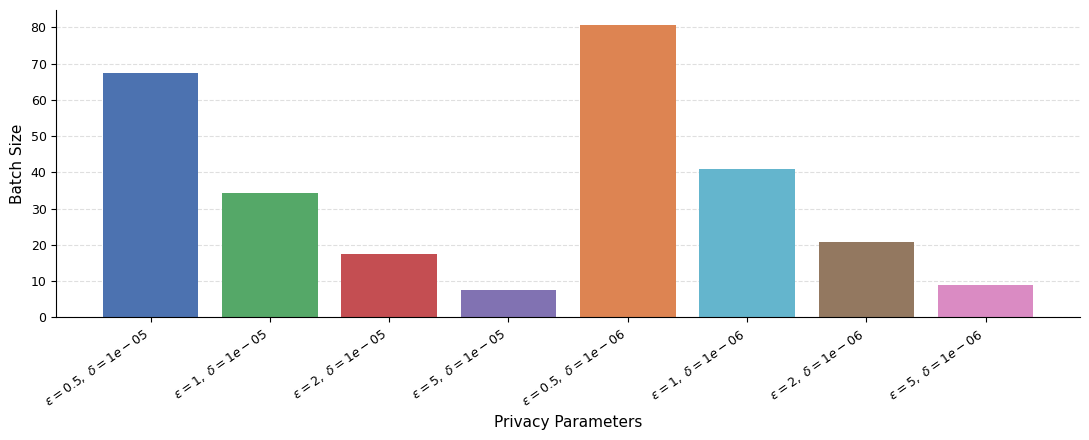

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

candidate_epsilons = [0.5, 1, 2, 5]
candidate_deltas = [1e-5, 1e-6]

def compute_U(eps, delta):
    return 2 * np.log2(1/delta) / eps + 1

pairs = [(eps, delta) for delta in candidate_deltas for eps in candidate_epsilons]
labels = [rf"$\epsilon={eps},\ \delta={delta}$" for eps, delta in pairs]
U_vals = [compute_U(eps, delta) for eps, delta in pairs]

x = np.arange(len(pairs))

# ICML typography
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig, ax = plt.subplots(figsize=(11, 4.5))

# Professional color palette
colors = [
    "#4C72B0", "#55A868", "#C44E52", "#8172B2",
    "#DD8452", "#64B5CD", "#937860", "#DA8BC3"
]

ax.bar(x, U_vals, color=colors[:len(x)], linewidth=0.5)

ax.set_xlabel("Privacy Parameters")
ax.set_ylabel("Batch Size")
#ax.set_title(r"Batch Size vs Privacy Parameters  ($U = \frac{2\log_2(1/\delta)}{\epsilon} + 1$)")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right")

# Grid + ICML styling
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()


plt.savefig("/content/drive/MyDrive/figure-randbin/batchsize_vs_privacy.pdf", bbox_inches="tight")


In [ ]:
exp_data=[]

In [ ]:
i=0
for data_noise in (data_noises):
  datastream,x=make_singular(n,dimension,noise=data_noise)
  random_order=np.random.permutation(datastream)
  for epsilon in (candidate_epsilons):
    for delta in (candidate_deltas):
      U=2*np.log2(1/delta)/epsilon+1
      model=main_alg(epsilon,delta,U,dimension,random_order,c1,c2,eta=0.05/U)
      model.simulate(iter=1)
      exp_data.append(copy.deepcopy([model.scores_users,model.scores_batches]))
      i+=1
      print(f'finish {i} round')

finish 1 round
finish 2 round
finish 3 round
finish 4 round
finish 5 round
finish 6 round
finish 7 round
finish 8 round
finish 9 round
finish 10 round
finish 11 round
finish 12 round
finish 13 round
finish 14 round
finish 15 round
finish 16 round
finish 17 round
finish 18 round
finish 19 round
finish 20 round
finish 21 round
finish 22 round
finish 23 round
finish 24 round


In [ ]:
data_noise=1
exp_data_fix_batch=[]

In [ ]:
len(exp_data_fix_batch)

8

In [ ]:
i=0
datastream,x=make_singular(n,dimension,noise=data_noise)
random_order=np.random.permutation(datastream)
for epsilon in (candidate_epsilons):
  for delta in (candidate_deltas):
    U=2*np.log2(1/delta)/epsilon+1
    model=main_alg(epsilon,delta,U,dimension,random_order,c1,c2,eta=0.05/U)
    model.simulate(iter=1)
    #exp_data.append(copy.deepcopy([model.scores_users,model.scores_batches]))
    model=main_alg(epsilon,delta,U,dimension,random_order,c1,c2,eta=0.05/U)
    model.simulate_fix_size()
    exp_data_fix_batch.append(copy.deepcopy([model.fix_batch_scores_users,model.fix_batch_scores_batches]))
    i+=1
    print(f'finish {i} round')

finish 1 round
finish 2 round
finish 3 round
finish 4 round
finish 5 round
finish 6 round
finish 7 round
finish 8 round


In [ ]:
with open('/content/drive/MyDrive/figure-randbin/compare_rdn_fix.pickle', 'wb') as f:
    pickle.dump([exp_data,exp_data_fix_batch], f)

In [ ]:
# with open('/content/drive/MyDrive/figure-randbin/compare_rdn_fix.pickle', 'rb') as file:
#     exp_data = pickle.load(file)

In [ ]:
data_noises

[0.01, 0.1, 1]

In [ ]:
len(exp_data)

24

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1813027199.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Objective Value w.r.t. Users, $\sigma={data_noise}$')


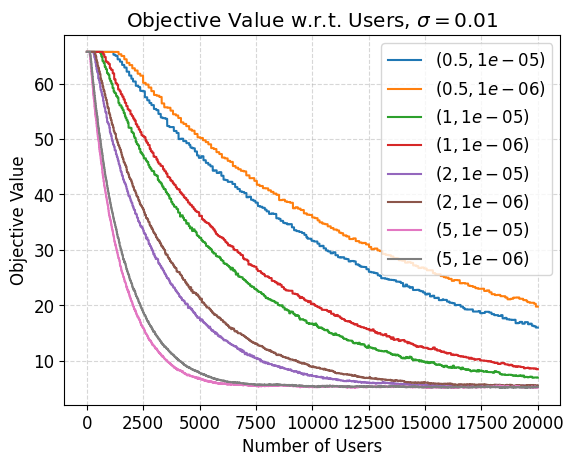

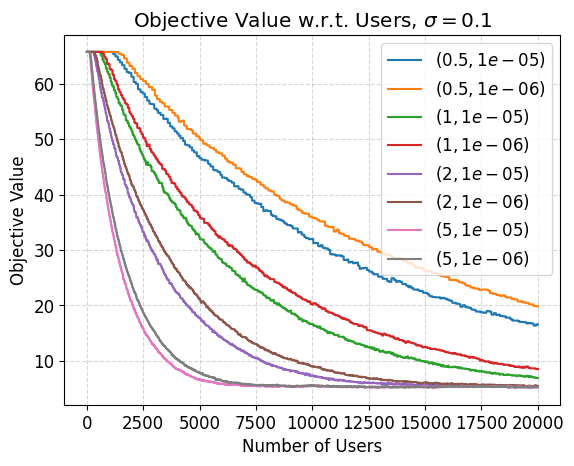

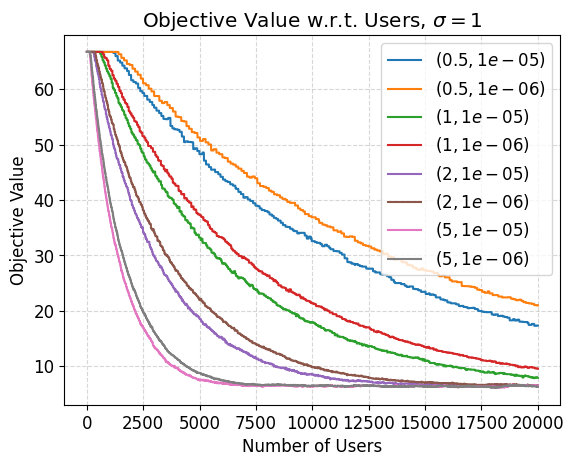

In [ ]:
for i,data_noise in enumerate(data_noises):
  plt.figure()
  for j,epsilon in enumerate(candidate_epsilons):
    for k,delta in enumerate(candidate_deltas):
      plt.plot(exp_data[8*i+2*j+k][0],label=f'$({epsilon},{float(delta)})$')
  plt.rcParams.update({'font.size': 12})
  plt.title(f'Objective Value w.r.t. Users, $\sigma={data_noise}$')
  plt.xlabel('Number of Users')
  plt.ylabel('Objective Value')
  #plt.xscale('log',base=2)
  plt.legend(loc='upper right')
  plt.grid(True, linestyle='--', alpha=0.5,zorder=0)
  plt.savefig(f'/content/drive/MyDrive/figure-randbin/users-sigma={data_noise}.pdf', bbox_inches = 'tight')
  plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-608389413.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Objective Value w.r.t. Batches, $\sigma={data_noise}$')


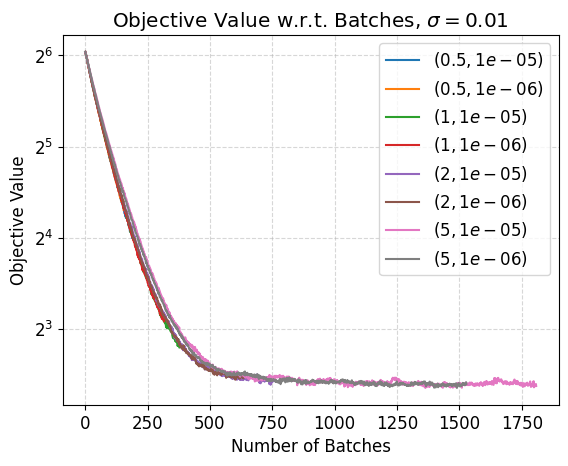

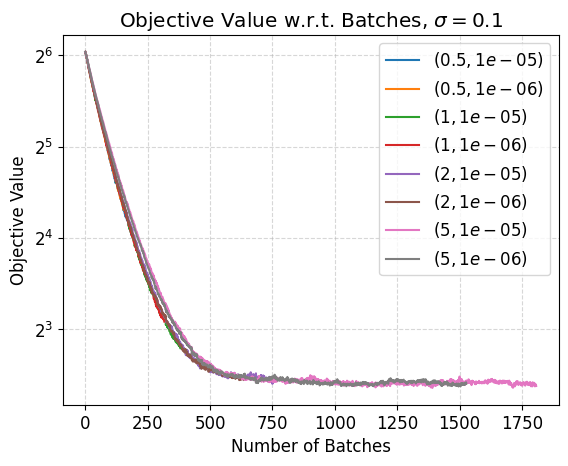

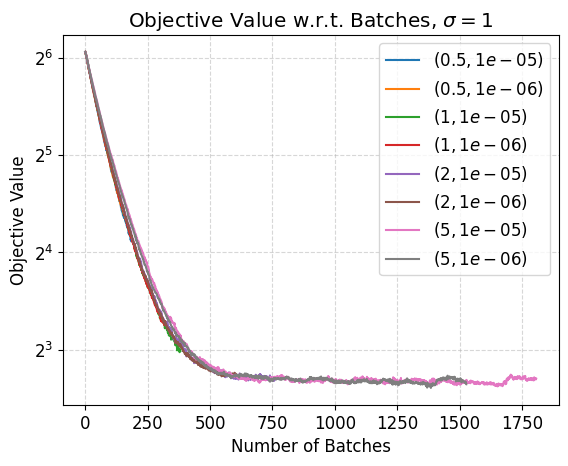

In [ ]:
for i,data_noise in enumerate(data_noises):
  plt.figure()
  for j,epsilon in enumerate(candidate_epsilons):

    for k,delta in enumerate(candidate_deltas):
      plt.plot(exp_data[8*i+2*j+k][1],label=f'$({epsilon},{delta})$')
  plt.rcParams.update({'font.size': 12})
  plt.title(f'Objective Value w.r.t. Batches, $\sigma={data_noise}$')
  plt.xlabel('Number of Batches')
  plt.ylabel('Objective Value')
  plt.yscale('log',base=2)
  plt.legend(loc='upper right')
  plt.grid(True, linestyle='--', alpha=0.5,zorder=0)
  plt.savefig(f'/content/drive/MyDrive/figure-randbin/batches-sigma={data_noise}.pdf', bbox_inches = 'tight')
  plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2977176580.py:5: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(exp_data[16+2*j+k][0],label=f'$\epsilon={epsilon}$')
/tmp/ipython-input-2977176580.py:6: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(exp_data_fix_batch[2*j+k][0],label=f'FS, $\epsilon={epsilon}$')
/tmp/ipython-input-2977176580.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Objective Value w.r.t. Users, $\sigma={data_noise}, \delta={delta}$')
/tmp/ipython-input-2977176580.py:8: SyntaxWarning: invalid escape sequence '\d'
  plt.title(f'Objective Value w.r.t. Users, $\sigma={data

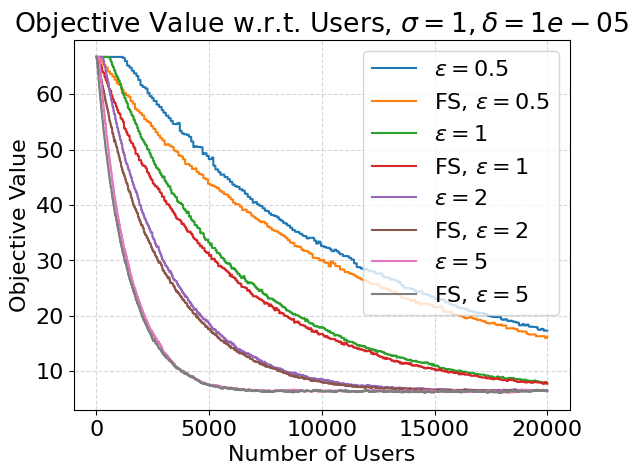

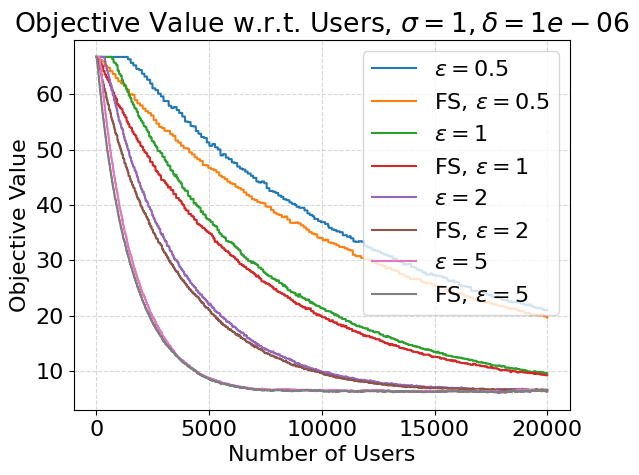

In [ ]:
for k,delta in enumerate(candidate_deltas):

  plt.figure()
  for j,epsilon in enumerate(candidate_epsilons):
    plt.plot(exp_data[16+2*j+k][0],label=f'$\epsilon={epsilon}$')
    plt.plot(exp_data_fix_batch[2*j+k][0],label=f'FS, $\epsilon={epsilon}$')
  plt.rcParams.update({'font.size': 16})
  plt.title(f'Objective Value w.r.t. Users, $\sigma={data_noise}, \delta={delta}$')
  plt.xlabel('Number of Users')
  plt.ylabel('Objective Value')
  #plt.xscale('log',base=2)
  plt.legend(loc='upper right')
  plt.grid(True, linestyle='--', alpha=0.5,zorder=0)
  plt.savefig(f'/content/drive/MyDrive/figure-randbin/fix-batch-users-sigma={data_noise},delta={delta}.pdf', bbox_inches = 'tight')
  plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2971687253.py:4: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(exp_data[16+2*j+k][0],label=f'$\delta={delta}$')
/tmp/ipython-input-2971687253.py:5: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(exp_data_fix_batch[2*j+k][0],label=f'FS, $\delta={delta}$')
/tmp/ipython-input-2971687253.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Objective Value w.r.t. Users, $\sigma={data_noise}, \epsilon={epsilon}$')
/tmp/ipython-input-2971687253.py:7: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Objective Value w.r.t. Users, $\sigma={data_noi

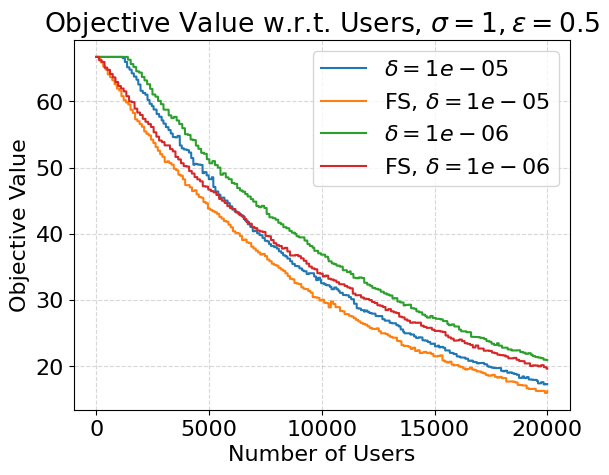

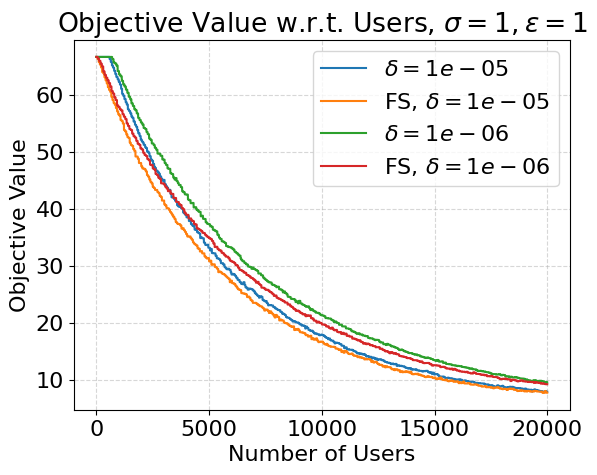

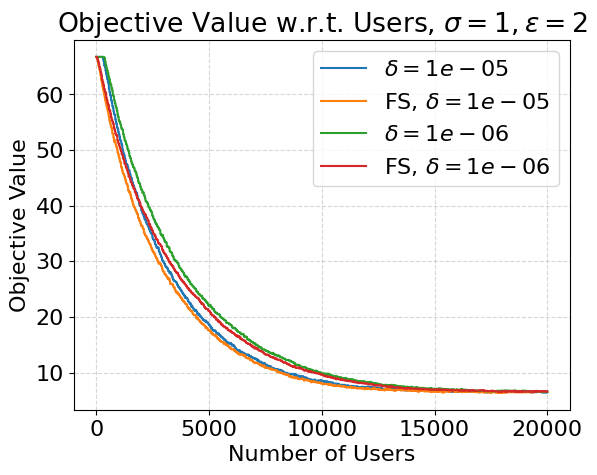

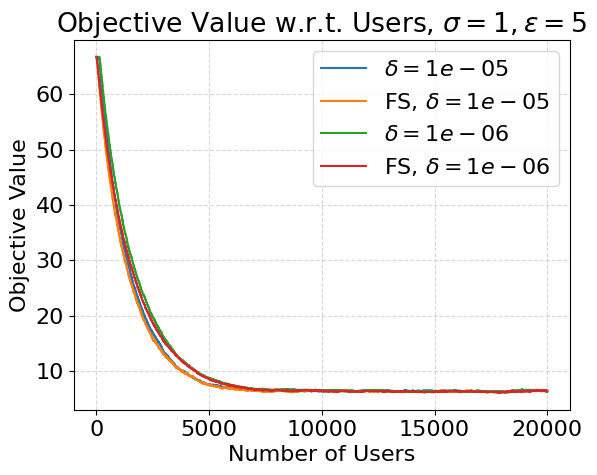

In [ ]:

for j,epsilon in enumerate(candidate_epsilons):
  plt.figure()
  for k,delta in enumerate(candidate_deltas):
    plt.plot(exp_data[16+2*j+k][0],label=f'$\delta={delta}$')
    plt.plot(exp_data_fix_batch[2*j+k][0],label=f'FS, $\delta={delta}$')
  plt.rcParams.update({'font.size': 16})
  plt.title(f'Objective Value w.r.t. Users, $\sigma={data_noise}, \epsilon={epsilon}$')
  plt.xlabel('Number of Users')
  plt.ylabel('Objective Value')
  #plt.xscale('log',base=2)
  plt.legend(loc='upper right')
  plt.grid(True, linestyle='--', alpha=0.5,zorder=0)
  plt.savefig(f'/content/drive/MyDrive/figure-randbin/fix-batch-users-sigma={data_noise},epsilon={epsilon}.pdf', bbox_inches = 'tight')
  plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2765448785.py:5: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(exp_data[j+k][1],label=f'$\delta={delta}$')
/tmp/ipython-input-2765448785.py:6: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(exp_data_fix_batch[j+k][1],label=f'FS, $\delta={delta}$')
/tmp/ipython-input-2765448785.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Objective Value w.r.t. Batches, $\sigma={data_noise}, \epsilon={epsilon}$')
/tmp/ipython-input-2765448785.py:8: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Objective Value w.r.t. Batches, $\sigma={data_noise}

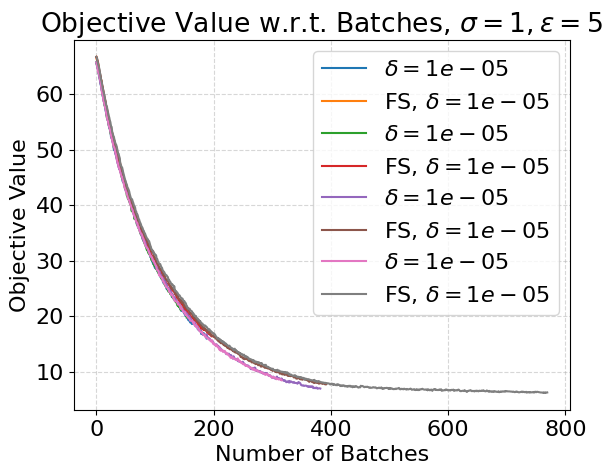

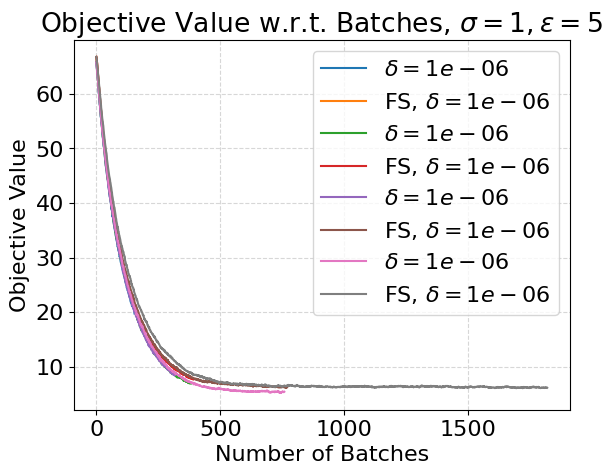

In [ ]:
for k,delta in enumerate(candidate_deltas):

  plt.figure()
  for j,epsilon in enumerate(candidate_epsilons):
    plt.plot(exp_data[j+k][1],label=f'$\delta={delta}$')
    plt.plot(exp_data_fix_batch[j+k][1],label=f'FS, $\delta={delta}$')
  plt.rcParams.update({'font.size': 16})
  plt.title(f'Objective Value w.r.t. Batches, $\sigma={data_noise}, \epsilon={epsilon}$')
  plt.xlabel('Number of Batches')
  plt.ylabel('Objective Value')
  #plt.xscale('log',base=2)
  plt.legend(loc='upper right')
  plt.grid(True, linestyle='--', alpha=0.5,zorder=0)
  plt.savefig(f'/content/drive/MyDrive/figure-randbin/fix-batch-batches-sigma={data_noise},delta={delta}.pdf', bbox_inches = 'tight')
  plt.show()

In [ ]:

for j,epsilon in enumerate(candidate_epsilons):
  plt.figure()

  for k,delta in enumerate(candidate_deltas):
    plt.plot(exp_data[3*j+k][1],label=f'$\delta={delta}$')
    plt.plot(exp_data_fix_batch[3*j+k][1],label=f'FS, $\delta={delta}$')
  plt.rcParams.update({'font.size': 16})
  plt.title(f'Objective Value w.r.t. Batches, $\sigma={data_noise}, \epsilon={epsilon}$')
  plt.xlabel('Number of Batches')
  plt.ylabel('Objective Value')
  #plt.xscale('log',base=2)
  plt.legend(loc='upper right')
  plt.grid(True, linestyle='--', alpha=0.5,zorder=0)
  plt.savefig(f'/content/drive/MyDrive/figure-randbin/fix-batch-batches-sigma={data_noise},epsilon={epsilon}.pdf', bbox_inches = 'tight')
  plt.show()